# Construcción del dataset inicial de mercado (EE.UU.)

Este notebook descarga datos públicos (Yahoo Finance y FRED), los limpia y los une en un panel diario para el TFM sobre **riesgo de mercado con Machine Learning**.

**Nota:** en esta fase no se entrenan modelos ni se define variable objetivo (target).

## 0. Librerías y fechas

Importamos las herramientas necesarias y fijamos el **rango de fechas del experimento** (fechas fijas en código para que el dataset sea reproducible al escribir la memoria del TFM).


In [11]:
%matplotlib inline

# Librerías para gráficos, datos y descargas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import yfinance as yf
from pandas_datareader import data as web

START_DATE = "1990-01-01"
# END_DATE fijada (no usamos la fecha del sistema) para que el CSV y las figuras coincidan siempre en el TFM
END_DATE = "2026-05-14"
# Yahoo interpreta `end` como exclusivo: sumamos 1 día para incluir el cierre del END_DATE
YF_END = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

print("Rango de descarga:", START_DATE, "->", END_DATE)


Rango de descarga: 1990-01-01 -> 2026-05-14


## 1. S&P 500 desde Yahoo Finance (`^GSPC`)

Descargamos precios diarios. Preferimos **cierre ajustado** (`Adj Close`) si existe; si no, usamos **cierre** (`Close`). La serie se renombra a `sp500_close`.

In [12]:
# Descarga del índice S&P 500 (OHLCV completo: es lo que guardaremos como "crudo" de Yahoo)
sp500_ohlcv_raw = yf.download("^GSPC", start=START_DATE, end=YF_END, progress=False, auto_adjust=False)

# Copia para limpiar nombres de columnas sin perder la tabla original
sp500_raw = sp500_ohlcv_raw.copy()

# yfinance a veces devuelve columnas tipo MultiIndex; lo dejamos en un solo nivel
if isinstance(sp500_raw.columns, pd.MultiIndex):
    sp500_raw.columns = sp500_raw.columns.droplevel(1)

# Elegimos cierre ajustado si está disponible (recomendado para series largas)
if "Adj Close" in sp500_raw.columns:
    sp500 = sp500_raw[["Adj Close"]].copy()
elif "Close" in sp500_raw.columns:
    sp500 = sp500_raw[["Close"]].copy()
else:
    raise ValueError("No se encontró ni Adj Close ni Close en los datos del S&P 500.")

sp500.columns = ["sp500_close"]

# Índice como fecha (sin hora) para alinear con FRED
sp500.index = pd.to_datetime(sp500.index).normalize()
sp500 = sp500.sort_index()

sp500.head()

,sp500_close
Date,
1990-01-02,359.690002
1990-01-03,358.760010
1990-01-04,355.670013
1990-01-05,352.200012
1990-01-08,353.790009


## 2. VIX desde FRED (`VIXCLS`)

El VIX es un índice de volatilidad implícita del mercado. FRED publica la serie diaria `VIXCLS`.

In [13]:
# Descarga desde FRED mediante pandas_datareader
vix = web.DataReader("VIXCLS", "fred", start=START_DATE, end=END_DATE)
vix.columns = ["vix"]
vix.index = pd.to_datetime(vix.index).normalize()
vix = vix.sort_index()

vix.head()

,vix
DATE,
1990-01-02,17.24
1990-01-03,18.19
1990-01-04,19.22
1990-01-05,20.11
1990-01-08,20.26


## 3. Tipos e spreads desde FRED

- `DGS10`, `DGS2`, `DGS3MO`: rendimientos constantes al vencimiento (en %).
- `T10Y2Y`, `T10Y3M`: spreads ya calculados entre vencimientos (en puntos porcentuales).

In [14]:
# Lista de códigos FRED y nombres cortos en nuestro dataset
fred_series = {
    "DGS10": "treasury_10y",
    "DGS2": "treasury_2y",
    "DGS3MO": "treasury_3m",
    "T10Y2Y": "spread_10y_2y",
    "T10Y3M": "spread_10y_3m",
}

parts = []
for code, colname in fred_series.items():
    s = web.DataReader(code, "fred", start=START_DATE, end=END_DATE)
    s.columns = [colname]
    s.index = pd.to_datetime(s.index).normalize()
    parts.append(s)

# Unimos las series FRED de tipos/spreads en una sola tabla alineada por fecha
rates = parts[0]
for s in parts[1:]:
    rates = rates.join(s, how="outer")
rates = rates.sort_index()

rates.head()

,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m
DATE,,,,,
1990-01-01,NaN,NaN,NaN,NaN,NaN
1990-01-02,7.94,7.87,7.83,0.07,0.11
1990-01-03,7.99,7.94,7.89,0.05,0.10
1990-01-04,7.98,7.92,7.84,0.06,0.14
1990-01-05,7.99,7.90,7.79,0.09,0.20


## 4. Guardar datos crudos en `data/raw/`

Guardamos copias de lo descargado **antes** de mezclar y transformar, para poder auditar o repetir el proceso.

In [15]:
from pathlib import Path

# El directorio de trabajo puede ser la raíz del repo o la carpeta `notebooks/` (según el IDE)
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Yahoo: tabla completa descargada + serie única usada en el merge
sp500_ohlcv_raw.to_csv(RAW_DIR / "sp500_yahoo_ohlcv_raw.csv")
sp500.to_csv(RAW_DIR / "sp500_yahoo_sp500_close_raw.csv")
vix.to_csv(RAW_DIR / "vix_fred_raw.csv")
rates.to_csv(RAW_DIR / "fred_rates_spreads_raw.csv")

print("Archivos guardados en:", RAW_DIR.resolve())

Archivos guardados en: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/raw


## 5. Unir por fecha, ordenar y tratar nulos

- Unimos **por índice de fechas** (unión externa para no perder días de ninguna fuente).
- Ordenamos de la fecha más antigua a la más reciente.
- Aplicamos **forward fill** (`ffill`) solo a las variables de FRED (tipos, spreads y VIX), porque a veces faltan valores en días de cotización.
- Eliminamos filas donde falte `sp500_close` (no tiene sentido una fila diaria de mercado sin el índice principal).

In [16]:
# Unión de todas las tablas por fecha
df = sp500.join(vix, how="outer").join(rates, how="outer")
df = df.sort_index()

# Columnas que provienen de FRED (incluye VIX y tipos/spreads)
fred_cols = ["vix"] + list(fred_series.values())

# Rellenar hacia adelante solo en columnas FRED
df[fred_cols] = df[fred_cols].ffill()

# Quitar días sin precio del S&P 500
df = df.dropna(subset=["sp500_close"])

df.head()

,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m
1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11
1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10
1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14
1990-01-05,352.200012,20.11,7.99,7.90,7.79,0.09,0.20
1990-01-08,353.790009,20.26,8.02,7.90,7.79,0.12,0.23


## 6. Variables derivadas

**Retornos y volatilidad del S&P 500**
- Retornos simples a 1, 5 y 20 días.
- `sp500_vol_20d`: volatilidad diaria (desviación típica de retornos a 20 días).
- `sp500_vol_20d_ann` y `sp500_vol_60d_ann`: mismas ideas anualizadas con `× √252` (252 días de cotización al año).

**Drawdown**
- `sp500_rolling_max_252d`: máximo del cierre en ventana móvil de 252 días hábiles (~1 año).
- `sp500_drawdown_252d`: cuánto cae el índice respecto a ese máximo (0 = en máximos; valores negativos = bajo el máximo reciente).

**Medias móviles**
- `sp500_ma_50`, `sp500_ma_200` y distancias relativas `sp500_dist_ma50`, `sp500_dist_ma200` (precio / media − 1).

**VIX**
- Cambios a 1 y 5 días; media móvil 20 días; `vix_zscore_252` (VIX frente a media y desviación móvil a 252 días).

**Tipos y spreads (FRED)**
- Cambios en 20 días (`diff(20)`) en puntos porcentuales.

**Curva de tipos**
- `curve_inverted_10y_2y`: entero (`int8`); vale **1** cuando la curva 10Y−2Y está invertida (spread < 0) y **0** si no.



In [17]:
# Retornos simples del índice (porcentaje de cambio respecto al cierre anterior)
df["sp500_return_1d"] = df["sp500_close"].pct_change(1)
df["sp500_return_5d"] = df["sp500_close"].pct_change(5)
df["sp500_return_20d"] = df["sp500_close"].pct_change(20)

# Volatilidad móvil a 20 días sobre retornos diarios (escala diaria, sin anualizar)
df["sp500_vol_20d"] = df["sp500_return_1d"].rolling(window=20).std()

# Volatilidades anualizadas: multiplicamos la desviación diaria por sqrt(252)
TRADING_DAYS = 252
df["sp500_vol_20d_ann"] = df["sp500_vol_20d"] * np.sqrt(TRADING_DAYS)
df["sp500_vol_60d_ann"] = (
    df["sp500_return_1d"].rolling(window=60).std() * np.sqrt(TRADING_DAYS)
)

# Drawdown a ~1 año: máximo rolling del precio y caída relativa respecto a ese máximo
df["sp500_rolling_max_252d"] = df["sp500_close"].rolling(window=252).max()
df["sp500_drawdown_252d"] = df["sp500_close"] / df["sp500_rolling_max_252d"] - 1

# Medias móviles del precio y distancia relativa (positivo = por encima de la media)
df["sp500_ma_50"] = df["sp500_close"].rolling(window=50).mean()
df["sp500_ma_200"] = df["sp500_close"].rolling(window=200).mean()
df["sp500_dist_ma50"] = df["sp500_close"] / df["sp500_ma_50"] - 1
df["sp500_dist_ma200"] = df["sp500_close"] / df["sp500_ma_200"] - 1

# Cambios absolutos del VIX (nivel actual menos nivel de hace N días)
df["vix_change_1d"] = df["vix"].diff(1)
df["vix_change_5d"] = df["vix"].diff(5)

# VIX: media móvil 20 días y z-score con ventana de 252 días (media y std rolling)
df["vix_ma_20"] = df["vix"].rolling(window=20).mean()
vix_mean_252 = df["vix"].rolling(window=252).mean()
vix_std_252 = df["vix"].rolling(window=252).std()
df["vix_zscore_252"] = (df["vix"] - vix_mean_252) / vix_std_252

# Cambios en tipos y spreads en 20 días (misma unidad que en FRED: puntos porcentuales)
df["treasury_10y_change_20d"] = df["treasury_10y"].diff(20)
df["treasury_2y_change_20d"] = df["treasury_2y"].diff(20)
df["spread_10y_2y_change_20d"] = df["spread_10y_2y"].diff(20)
df["spread_10y_3m_change_20d"] = df["spread_10y_3m"].diff(20)

# Curva 10Y−2Y invertida: 1 si spread < 0, 0 en caso contrario (entero int8)
# Tras el forward fill de FRED, `spread_10y_2y` no queda con nulos en las filas del dataset
df["curve_inverted_10y_2y"] = (df["spread_10y_2y"] < 0).astype("int8")

df.head(10)



,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,sp500_return_20d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,NaN,...,NaN,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,NaN,...,NaN,1.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-05,352.200012,20.11,7.99,7.90,7.79,0.09,0.20,-0.009756,NaN,NaN,...,NaN,0.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-08,353.790009,20.26,8.02,7.90,7.79,0.12,0.23,0.004514,NaN,NaN,...,NaN,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-09,349.619995,22.20,8.02,7.91,7.80,0.11,0.22,-0.011787,-0.027996,NaN,...,NaN,1.94,4.96,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-10,347.309998,22.44,8.03,7.91,7.75,0.12,0.28,-0.006607,-0.031916,NaN,...,NaN,0.24,4.25,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-11,348.529999,20.05,8.04,7.91,7.80,0.13,0.24,0.003513,-0.020075,NaN,...,NaN,-2.39,0.83,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-12,339.929993,24.64,8.10,7.93,7.74,0.17,0.36,-0.024675,-0.034838,NaN,...,NaN,4.59,4.53,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-15,337.000000,26.34,8.10,7.93,7.74,0.17,0.36,-0.008619,-0.047458,NaN,...,NaN,1.70,6.08,NaN,NaN,NaN,NaN,NaN,NaN,0


## 7. Guardar el dataset procesado

Exportamos la tabla final a CSV en `data/processed/`.

In [18]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

out_path = PROCESSED_DIR / "initial_market_dataset.csv"
# index_label="date" deja claro en el CSV que la primera columna es la fecha
df.to_csv(out_path, index_label="date")

print("Dataset procesado guardado en:", out_path.resolve())



Dataset procesado guardado en: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/initial_market_dataset.csv


## 8. Resumen y gráficos exploratorios

Resumen global del dataset, nulos, vistazo al `DataFrame`, documentación por **familias de variables** y gráficos del S&P 500, del VIX y del drawdown a 252 días.


In [19]:
# --- Tabla resumen del dataset ---
n_rows, n_cols = df.shape
fecha_inicio = df.index.min()
fecha_fin = df.index.max()
null_pct = (df.isna().mean() * 100).round(2)

resumen = pd.DataFrame(
    {
        "valor": [
            n_rows,
            n_cols,
            str(fecha_inicio.date()),
            str(fecha_fin.date()),
        ]
    },
    index=["n_filas", "n_columnas", "fecha_inicial", "fecha_final"],
)

print("Resumen del dataset:")
display(resumen)

print("\nPorcentaje de valores nulos por columna (%):")
display(null_pct.to_frame(name="pct_nulos"))

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

print("\nInformación del DataFrame:")
df.info()



Resumen del dataset:


,valor
n_filas,9159
n_columnas,28
fecha_inicial,1990-01-02
fecha_final,2026-05-14



Porcentaje de valores nulos por columna (%):


,pct_nulos
sp500_close,0.00
vix,0.00
treasury_10y,0.00
treasury_2y,0.00
treasury_3m,0.00
spread_10y_2y,0.00
spread_10y_3m,0.00
sp500_return_1d,0.01
sp500_return_5d,0.05
sp500_return_20d,0.22



Primeras filas:


,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,sp500_return_20d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,NaN,...,NaN,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,NaN,...,NaN,1.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-05,352.200012,20.11,7.99,7.90,7.79,0.09,0.20,-0.009756,NaN,NaN,...,NaN,0.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1990-01-08,353.790009,20.26,8.02,7.90,7.79,0.12,0.23,0.004514,NaN,NaN,...,NaN,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0



Últimas filas:


,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,sp500_return_20d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
2026-05-08,7398.930176,17.19,4.38,3.90,3.69,0.48,0.69,0.008426,0.023348,0.085382,...,0.095584,0.11,0.20,18.1125,-0.321818,0.07,0.09,-0.02,0.07,0
2026-05-11,7412.839844,18.38,4.42,3.95,3.70,0.47,0.72,0.001880,0.029454,0.076471,...,0.096792,1.19,0.09,18.0755,0.043813,0.12,0.17,-0.05,0.13,0
2026-05-12,7400.959961,17.99,4.46,4.00,3.70,0.46,0.76,-0.001603,0.019525,0.062230,...,0.094215,-0.39,0.61,18.0570,-0.070199,0.20,0.24,-0.04,0.21,0
2026-05-13,7444.250000,17.87,4.46,3.98,3.69,0.48,0.77,0.005849,0.010744,0.059989,...,0.099758,-0.12,0.48,18.0420,-0.106138,0.17,0.22,-0.05,0.19,0
2026-05-14,7501.240234,17.26,4.47,4.00,3.69,0.47,0.78,0.007656,0.022370,0.065323,...,0.107252,-0.61,0.18,18.0080,-0.290817,0.15,0.22,-0.07,0.16,0



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9159 entries, 1990-01-02 to 2026-05-14
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sp500_close               9159 non-null   float64
 1   vix                       9159 non-null   float64
 2   treasury_10y              9159 non-null   float64
 3   treasury_2y               9159 non-null   float64
 4   treasury_3m               9159 non-null   float64
 5   spread_10y_2y             9159 non-null   float64
 6   spread_10y_3m             9159 non-null   float64
 7   sp500_return_1d           9158 non-null   float64
 8   sp500_return_5d           9154 non-null   float64
 9   sp500_return_20d          9139 non-null   float64
 10  sp500_vol_20d             9139 non-null   float64
 11  sp500_vol_20d_ann         9139 non-null   float64
 12  sp500_vol_60d_ann         9099 non-null   float64
 13  sp500_rolling_max

### Sobre los valores nulos

Ver **muchos NaN al inicio** de algunas columnas es esperable: las variables calculadas con ventanas móviles (rolling) necesitan acumular historia (por ejemplo **20, 60, 200 o 252** días de cotización) antes de poder calcularse. En este notebook **no eliminamos ni rellenamos** esos nulos; el CSV guardado los deja tal cual para que decidas más adelante cómo tratarlos.


### Familias de variables

La siguiente tabla resume **qué dimensiones financieras** agrupa cada bloque de columnas; sirve para documentar el dataset en la memoria del TFM.


In [20]:
# Agrupación interpretable de columnas (solo documentación; no cambia el dataset)
feature_families = pd.DataFrame(
    {
        "familia": [
            "Mercado S&P 500",
            "Volatilidad implícita",
            "Tipos de interés",
            "Curva de tipos",
            "Cambios recientes",
        ],
        "variables": [
            "sp500_close, sp500_return_1d, sp500_return_5d, sp500_return_20d, sp500_vol_20d, sp500_vol_20d_ann, sp500_vol_60d_ann, sp500_rolling_max_252d, sp500_drawdown_252d, sp500_ma_50, sp500_ma_200, sp500_dist_ma50, sp500_dist_ma200",
            "vix, vix_change_1d, vix_change_5d, vix_ma_20, vix_zscore_252",
            "treasury_10y, treasury_2y, treasury_3m",
            "spread_10y_2y, spread_10y_3m, curve_inverted_10y_2y",
            "treasury_10y_change_20d, treasury_2y_change_20d, spread_10y_2y_change_20d, spread_10y_3m_change_20d",
        ],
    }
)

display(feature_families)


,familia,variables
0,Mercado S&P 500,"sp500_close, sp500_return_1d, sp500_return_5d,..."
1,Volatilidad implícita,"vix, vix_change_1d, vix_change_5d, vix_ma_20, ..."
2,Tipos de interés,"treasury_10y, treasury_2y, treasury_3m"
3,Curva de tipos,"spread_10y_2y, spread_10y_3m, curve_inverted_1..."
4,Cambios recientes,"treasury_10y_change_20d, treasury_2y_change_20..."


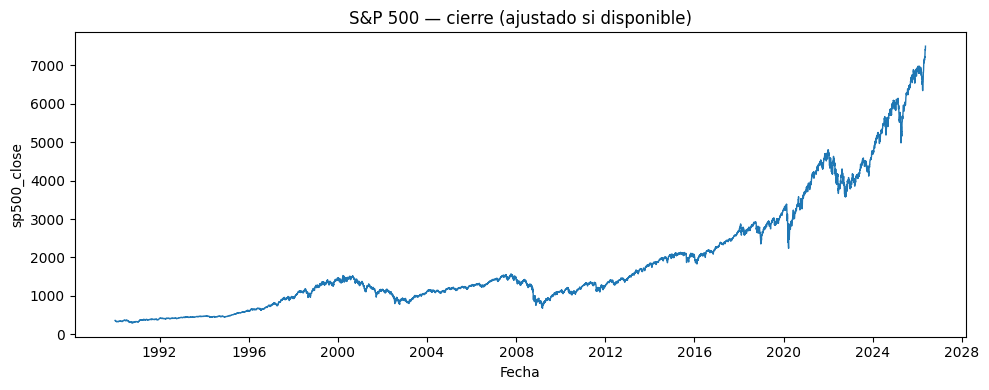

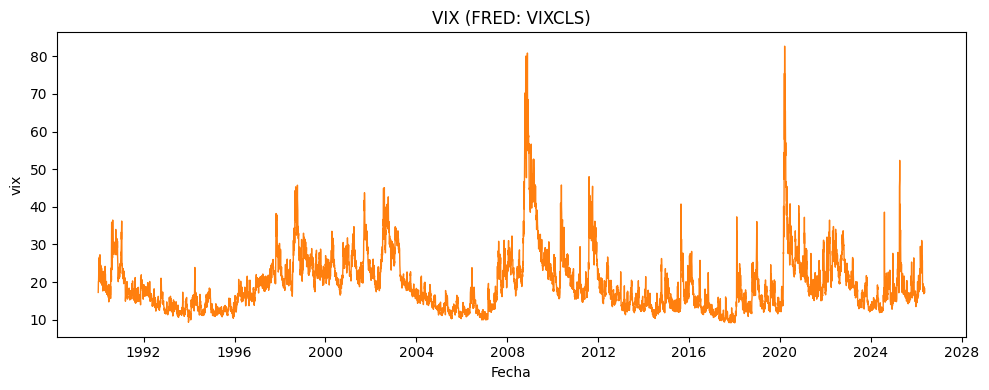

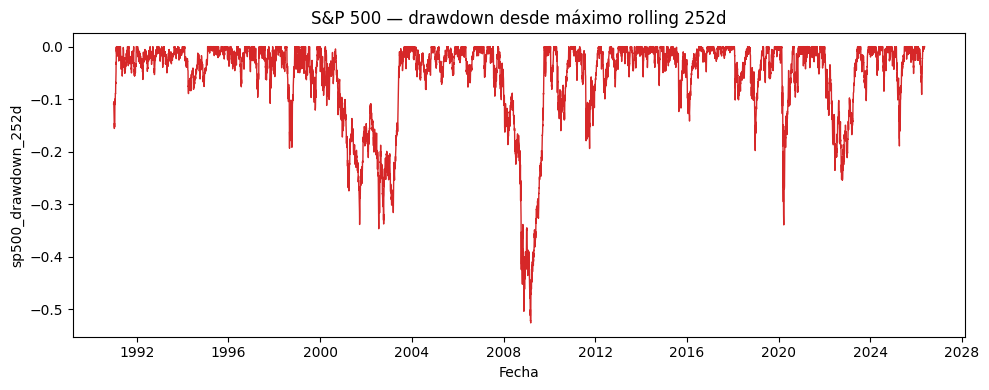

In [21]:
# Gráfico simple del nivel del S&P 500
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["sp500_close"], color="tab:blue", linewidth=1)
plt.title("S&P 500 — cierre (ajustado si disponible)")
plt.xlabel("Fecha")
plt.ylabel("sp500_close")
plt.tight_layout()
plt.show()

# Gráfico simple del VIX
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["vix"], color="tab:orange", linewidth=1)
plt.title("VIX (FRED: VIXCLS)")
plt.xlabel("Fecha")
plt.ylabel("vix")
plt.tight_layout()
plt.show()

# Drawdown a 252 días (valores cercanos a 0 = cerca del máximo reciente; negativos = corrección)
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["sp500_drawdown_252d"], color="tab:red", linewidth=1)
plt.title("S&P 500 — drawdown desde máximo rolling 252d")
plt.xlabel("Fecha")
plt.ylabel("sp500_drawdown_252d")
plt.tight_layout()
plt.show()

